# Customer Segmentation & Sales Forecasting
**Author:** Muskan Saxena  
**Dataset:** Online Retail II — UCI Machine Learning Repository  
**Tools:** Python, Pandas, Scikit-learn, Statsmodels, Matplotlib, Seaborn, Plotly

---

## Project Overview

This project has two parts:

**Part 1 — Customer Segmentation**  
Using RFM (Recency, Frequency, Monetary) analysis and K-Means clustering to segment customers into behavioral groups, then profiling each segment for business strategy.

**Part 2 — Sales Forecasting**  
Building a hybrid forecasting pipeline combining ARIMA for trend extrapolation and Random Forest regression for feature-rich short-term prediction.

---

## Dataset
- Source: [Online Retail II — Kaggle](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci)
- ~1 million transactions from a UK-based online retailer (2009–2011)
- Features: InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# Install required libraries (run this in Colab)
# !pip install plotly statsmodels scikit-learn openpyxl

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

# Statsmodels
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('All libraries loaded successfully!')

All libraries loaded successfully!


---
## Step 1 — Load & Explore the Data

Before loading the data, we need to extract the `online_retail_II.xlsx` file from the zipped archive `online_retail_II.xlsx.zip` located in your Google Drive.

In [15]:
# Unzip the dataset from Google Drive
!unzip -o '/content/drive/MyDrive/online_retail_II.xlsx.zip' -d '/content/'

print('Dataset unzipped successfully to /content/')


Archive:  /content/drive/MyDrive/online_retail_II.xlsx.zip
  inflating: /content/online_retail_II.csv  
Dataset unzipped successfully to /content/


In [16]:
# Load dataset
df = pd.read_csv('/content/online_retail_II.csv')

print('Dataset shape:', df.shape)
print('\nColumn names:', df.columns.tolist())
print('\nDate range:', df['InvoiceDate'].min(), 'to', df['InvoiceDate'].max())
df.head()

Dataset shape: (1067371, 8)

Column names: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [17]:
# Basic info
print('=== Dataset Info ===')
print(f'Total rows: {df.shape[0]:,}')
print(f'Total columns: {df.shape[1]}')
print(f'\nMissing values:')
print(df.isnull().sum())
print(f'\nData types:')
print(df.dtypes)

=== Dataset Info ===
Total rows: 1,067,371
Total columns: 8

Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Data types:
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object


---
## Step 2 — Data Cleaning

In [18]:
print(f'Shape before cleaning: {df.shape}')

# Drop rows with missing CustomerID — can't do RFM without customer identifier
df = df.dropna(subset=['Customer ID'])
print(f'After dropping missing CustomerID: {df.shape}')

# Remove cancelled invoices (start with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]
print(f'After removing cancellations: {df.shape}')

# Remove rows with Quantity <= 0 or Price <= 0
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
print(f'After removing negative quantities/prices: {df.shape}')

# Remove duplicate rows
df = df.drop_duplicates()
print(f'After removing duplicates: {df.shape}')

# Create TotalAmount column
df['TotalAmount'] = df['Quantity'] * df['Price']

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extract date components for feature engineering
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Week'] = df['InvoiceDate'].dt.isocalendar().week.astype(int)
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['Date'] = df['InvoiceDate'].dt.date

# Convert CustomerID to integer
df['Customer ID'] = df['Customer ID'].astype(int)

print(f'\nFinal clean dataset shape: {df.shape}')
print('\nSample cleaned data:')
df.head()

Shape before cleaning: (1067371, 8)
After dropping missing CustomerID: (824364, 8)
After removing cancellations: (805620, 8)
After removing negative quantities/prices: (805549, 8)
After removing duplicates: (779425, 8)

Final clean dataset shape: (779425, 14)

Sample cleaned data:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount,Year,Month,Week,DayOfWeek,Date
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,49,1,2009-12-01
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,49,1,2009-12-01
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,49,1,2009-12-01
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,49,1,2009-12-01
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,49,1,2009-12-01


---
## Step 3 — Exploratory Data Analysis

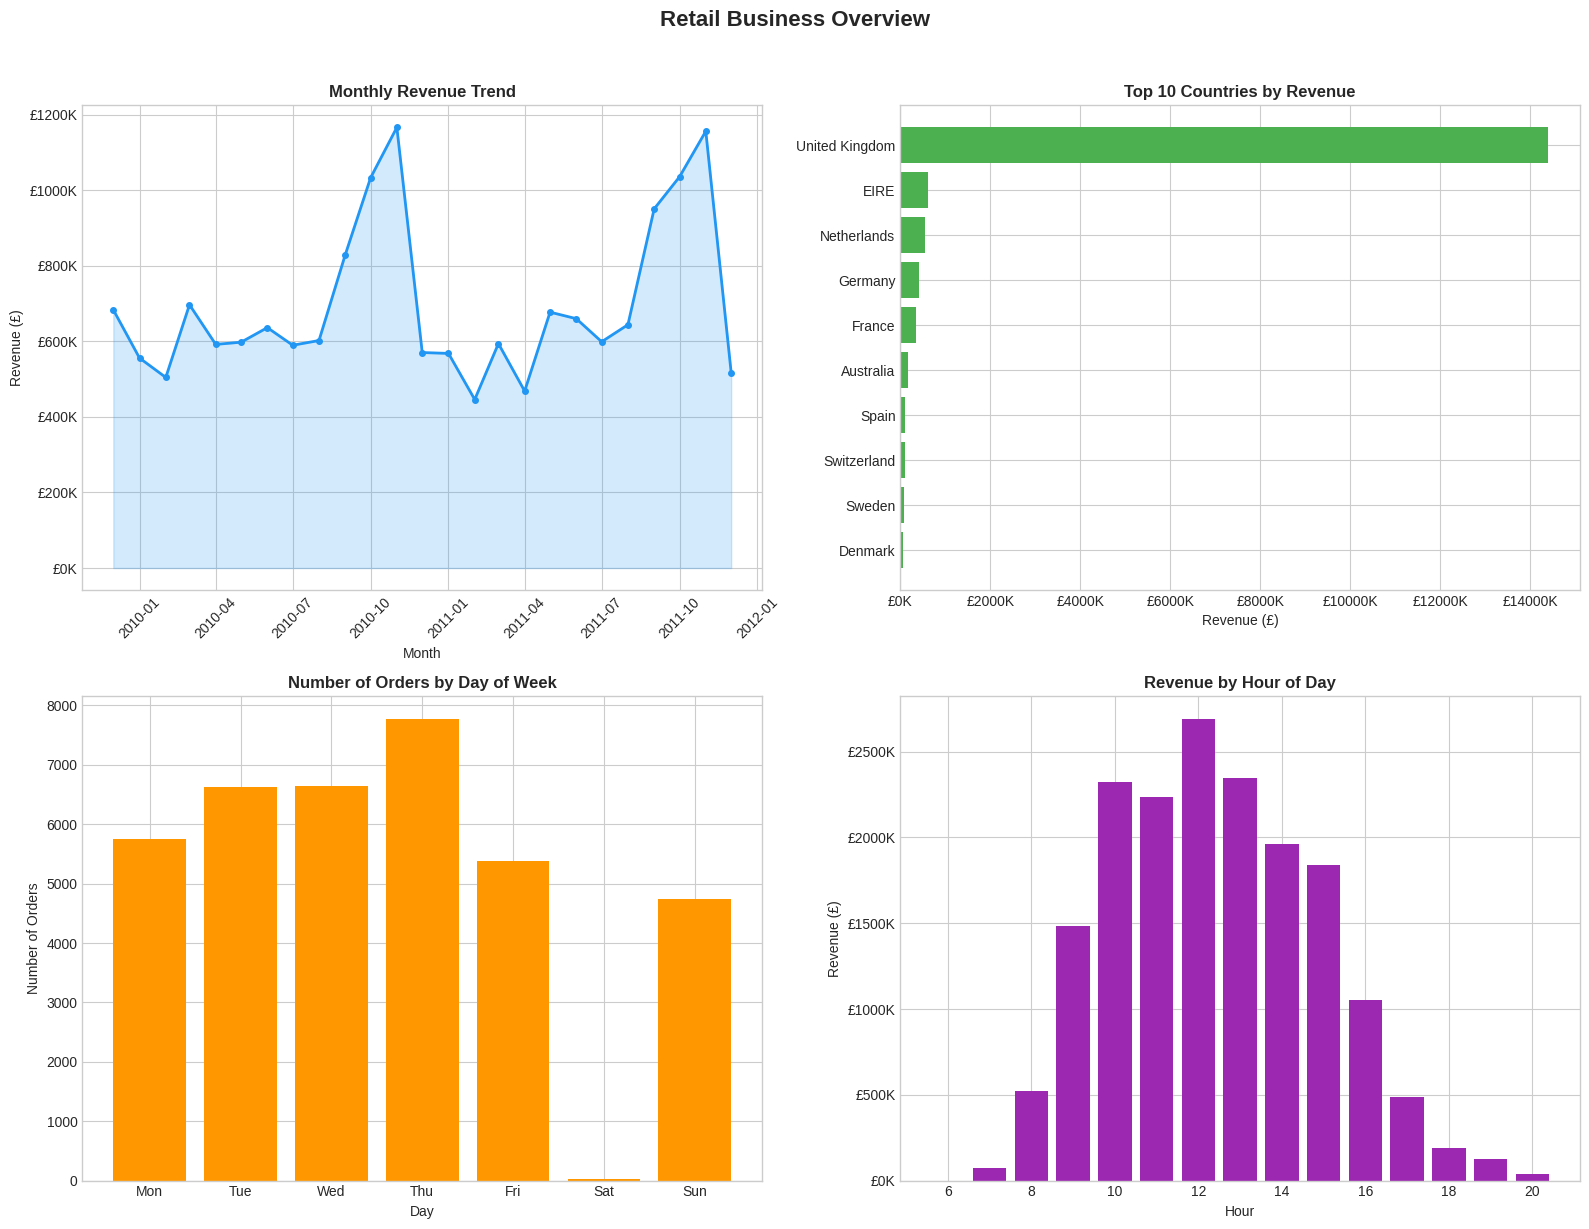

EDA charts saved!


In [19]:
# Monthly revenue trend
monthly_revenue = df.groupby(['Year', 'Month'])['TotalAmount'].sum().reset_index()
monthly_revenue['Period'] = pd.to_datetime(
    monthly_revenue['Year'].astype(str) + '-' + monthly_revenue['Month'].astype(str), format='%Y-%m'
)
monthly_revenue = monthly_revenue.sort_values('Period')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Retail Business Overview', fontsize=16, fontweight='bold', y=1.02)

# Plot 1 — Monthly Revenue Trend
axes[0,0].plot(monthly_revenue['Period'], monthly_revenue['TotalAmount'],
               color='#2196F3', linewidth=2, marker='o', markersize=4)
axes[0,0].fill_between(monthly_revenue['Period'], monthly_revenue['TotalAmount'], alpha=0.2, color='#2196F3')
axes[0,0].set_title('Monthly Revenue Trend', fontweight='bold')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Revenue (£)')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2 — Top 10 Countries by Revenue
country_revenue = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)
axes[0,1].barh(country_revenue.index[::-1], country_revenue.values[::-1], color='#4CAF50')
axes[0,1].set_title('Top 10 Countries by Revenue', fontweight='bold')
axes[0,1].set_xlabel('Revenue (£)')
axes[0,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

# Plot 3 — Orders by Day of Week
day_orders = df.groupby('DayOfWeek')['Invoice'].nunique()
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1,0].bar(day_labels[:len(day_orders)], day_orders.values, color='#FF9800')
axes[1,0].set_title('Number of Orders by Day of Week', fontweight='bold')
axes[1,0].set_xlabel('Day')
axes[1,0].set_ylabel('Number of Orders')

# Plot 4 — Revenue by Hour
df['Hour'] = df['InvoiceDate'].dt.hour
hourly_revenue = df.groupby('Hour')['TotalAmount'].sum()
axes[1,1].bar(hourly_revenue.index, hourly_revenue.values, color='#9C27B0')
axes[1,1].set_title('Revenue by Hour of Day', fontweight='bold')
axes[1,1].set_xlabel('Hour')
axes[1,1].set_ylabel('Revenue (£)')
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA charts saved!')

---
## Part 1 — Customer Segmentation (RFM + K-Means)

**RFM Analysis:**
- **Recency** — How recently did the customer purchase? (lower = better)
- **Frequency** — How often do they buy?
- **Monetary** — How much do they spend in total?

In [20]:
# Set reference date as one day after last transaction
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Reference date for Recency calculation: {reference_date.date()}')

# Build RFM table
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('TotalAmount', 'sum')
).reset_index()

print(f'\nRFM table shape: {rfm.shape}')
print(f'\nRFM Summary Statistics:')
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))

Reference date for Recency calculation: 2011-12-10

RFM table shape: (5878, 4)

RFM Summary Statistics:
       Recency  Frequency   Monetary
count  5878.00    5878.00    5878.00
mean    201.33       6.29    2955.90
std     209.34      13.01   14440.85
min       1.00       1.00       2.95
25%      26.00       1.00     342.28
50%      96.00       3.00     867.74
75%     380.00       7.00    2248.30
max     739.00     398.00  580987.04


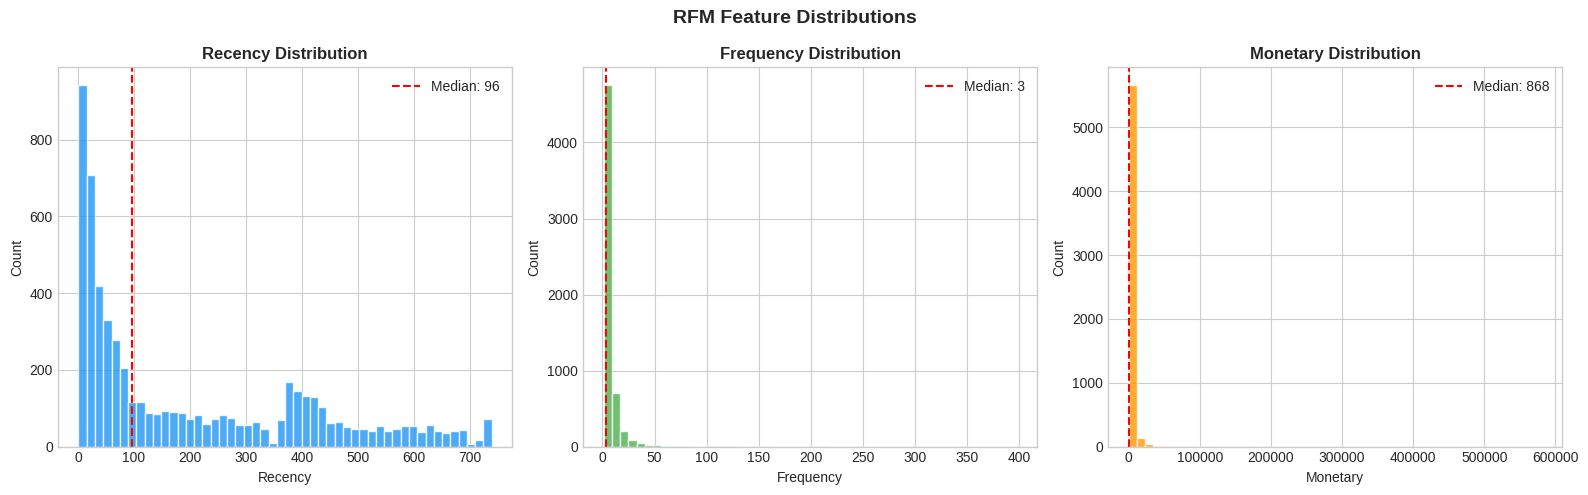

In [21]:
# Visualize RFM distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RFM Feature Distributions', fontsize=14, fontweight='bold')

colors = ['#2196F3', '#4CAF50', '#FF9800']
for idx, (col, color) in enumerate(zip(['Recency', 'Frequency', 'Monetary'], colors)):
    axes[idx].hist(rfm[col], bins=50, color=color, alpha=0.8, edgecolor='white')
    axes[idx].set_title(f'{col} Distribution', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].axvline(rfm[col].median(), color='red', linestyle='--', label=f'Median: {rfm[col].median():.0f}')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('rfm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

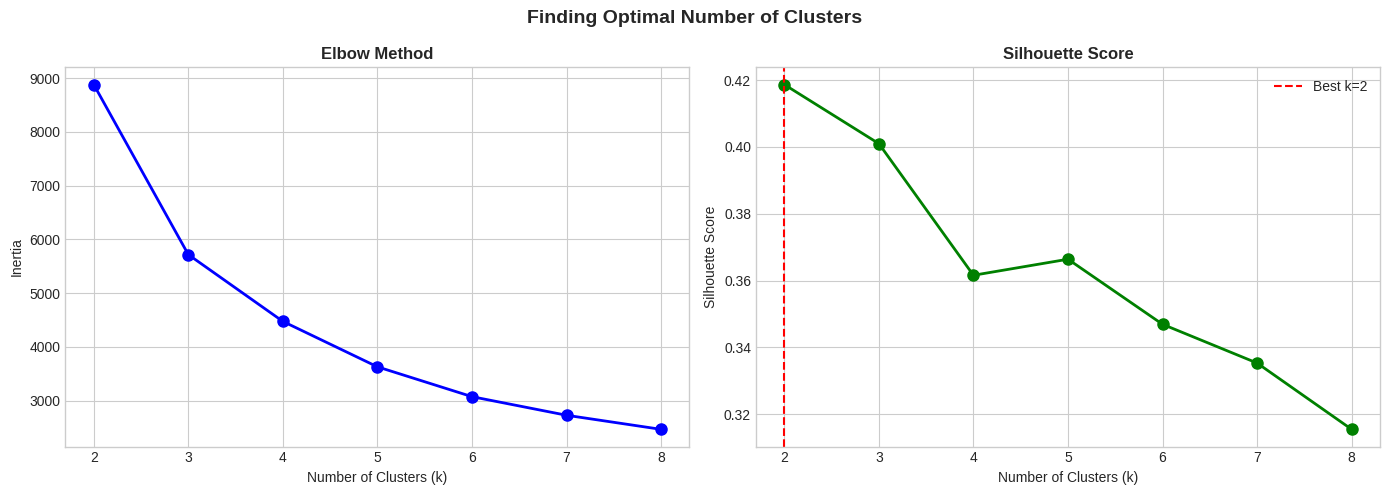

Best k by Silhouette Score: 2 (score: 0.419)


In [22]:
# Log transform Monetary and Frequency to handle skew
rfm_log = rfm.copy()
rfm_log['Monetary'] = np.log1p(rfm['Monetary'])
rfm_log['Frequency'] = np.log1p(rfm['Frequency'])

# Scale features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[['Recency', 'Frequency', 'Monetary']])

# Find optimal k using Elbow Method + Silhouette Score
inertia = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, km.labels_))

# Plot Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Finding Optimal Number of Clusters', fontsize=14, fontweight='bold')

axes[0].plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

best_k = k_range[np.argmax(silhouette_scores)]
axes[1].axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
axes[1].legend()

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best k by Silhouette Score: {best_k} (score: {max(silhouette_scores):.3f})')

In [23]:
# Apply K-Means with optimal k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(f'K-Means applied with k={best_k}')
print(f'Silhouette Score: {silhouette_score(rfm_scaled, rfm["Cluster"]):.3f}')
print(f'\nCustomers per cluster:')
print(rfm['Cluster'].value_counts().sort_index())

K-Means applied with k=2
Silhouette Score: 0.419

Customers per cluster:
Cluster
0    3179
1    2699
Name: count, dtype: int64


In [24]:
# Cluster profiling
cluster_profile = rfm.groupby('Cluster').agg(
    Customers  = ('Customer ID', 'count'),
    Avg_Recency   = ('Recency', 'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary', 'mean'),
    Total_Revenue = ('Monetary', 'sum')
).round(2)

# Label clusters based on profile
# (You may need to adjust labels based on your actual results)
def label_cluster(row):
    if row['Avg_Recency'] < 30 and row['Avg_Frequency'] > 10:
        return 'Champions'
    elif row['Avg_Recency'] < 60 and row['Avg_Frequency'] > 5:
        return 'Loyal Customers'
    elif row['Avg_Recency'] > 200:
        return 'Lost Customers'
    elif row['Avg_Frequency'] < 3:
        return 'New / Occasional'
    else:
        return 'At Risk'

cluster_profile['Segment'] = cluster_profile.apply(label_cluster, axis=1)
print('=== Cluster Profile ===')
print(cluster_profile)

=== Cluster Profile ===
         Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue  \
Cluster                                                                       
0             3179       317.97           1.85        521.74     1658614.22   
1             2699        63.95          11.52       5822.97    15716190.04   

                Segment  
Cluster                  
0        Lost Customers  
1               At Risk  


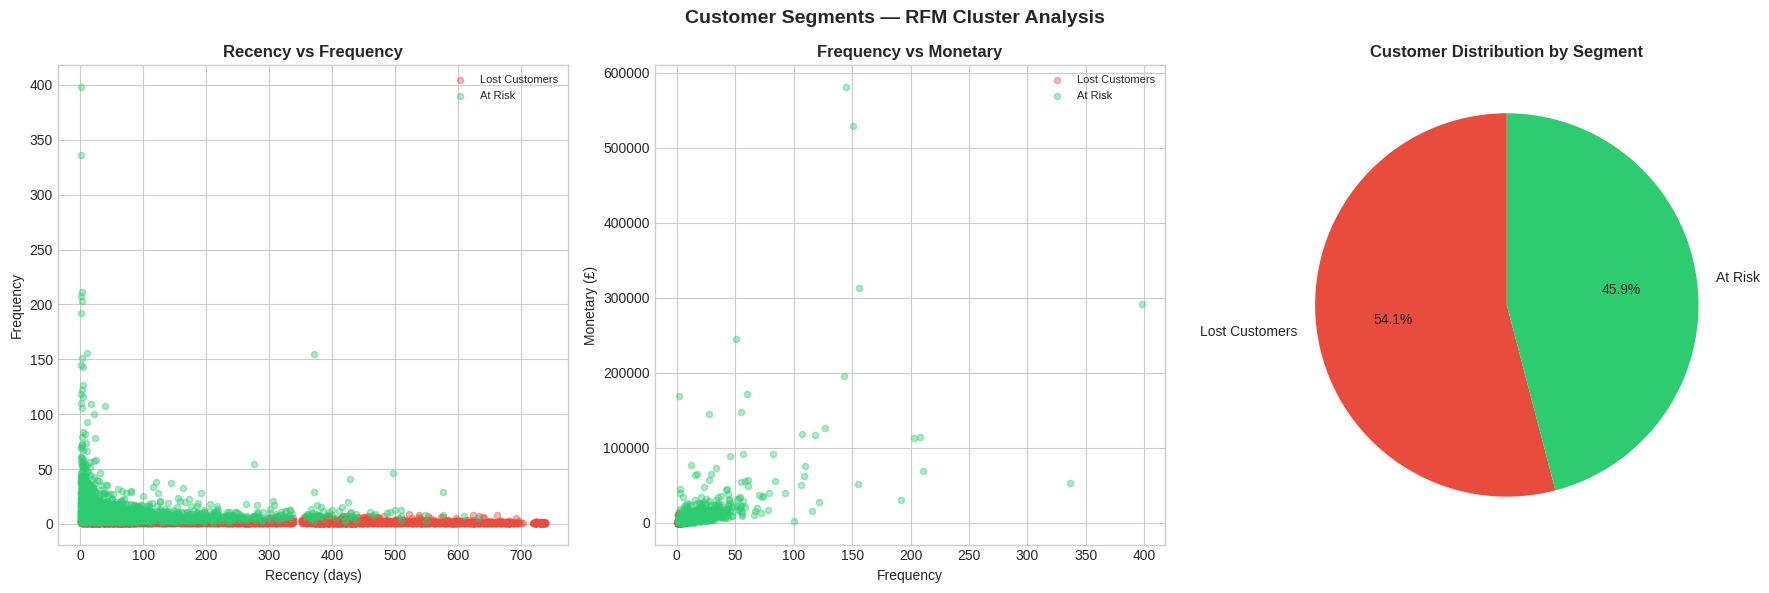

In [25]:
# Visualize clusters
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Customer Segments — RFM Cluster Analysis', fontsize=14, fontweight='bold')

colors_cluster = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12', '#9B59B6']

# Recency vs Frequency
for cluster in sorted(rfm['Cluster'].unique()):
    mask = rfm['Cluster'] == cluster
    label = cluster_profile.loc[cluster, 'Segment'] if cluster in cluster_profile.index else f'Cluster {cluster}'
    axes[0].scatter(rfm[mask]['Recency'], rfm[mask]['Frequency'],
                    alpha=0.4, s=20, c=colors_cluster[cluster], label=label)
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Recency vs Frequency', fontweight='bold')
axes[0].legend(fontsize=8)

# Frequency vs Monetary
for cluster in sorted(rfm['Cluster'].unique()):
    mask = rfm['Cluster'] == cluster
    label = cluster_profile.loc[cluster, 'Segment'] if cluster in cluster_profile.index else f'Cluster {cluster}'
    axes[1].scatter(rfm[mask]['Frequency'], rfm[mask]['Monetary'],
                    alpha=0.4, s=20, c=colors_cluster[cluster], label=label)
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Monetary (£)')
axes[1].set_title('Frequency vs Monetary', fontweight='bold')
axes[1].legend(fontsize=8)

# Cluster size pie chart
cluster_sizes = rfm['Cluster'].value_counts().sort_index()
segment_labels = [cluster_profile.loc[i, 'Segment'] if i in cluster_profile.index else f'Cluster {i}'
                  for i in cluster_sizes.index]
axes[2].pie(cluster_sizes.values, labels=segment_labels,
            colors=colors_cluster[:len(cluster_sizes)],
            autopct='%1.1f%%', startangle=90)
axes[2].set_title('Customer Distribution by Segment', fontweight='bold')

plt.tight_layout()
plt.savefig('cluster_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

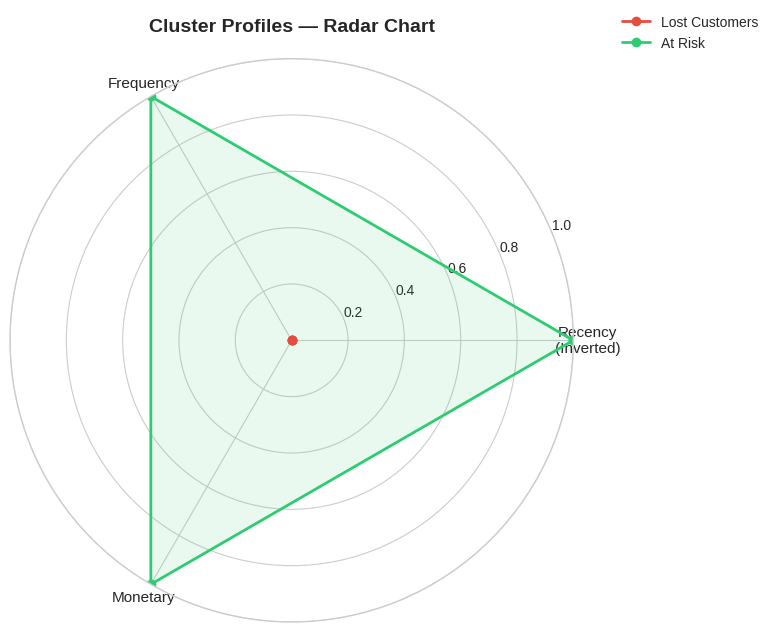

In [27]:
# Radar chart for cluster profiles
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Normalize RFM values for radar
radar_df = cluster_profile[['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary']].copy()
# Invert recency — lower recency is better
radar_df['Avg_Recency'] = radar_df['Avg_Recency'].max() - radar_df['Avg_Recency']
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min())

categories = ['Recency\n(Inverted)', 'Frequency', 'Monetary']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_title('Cluster Profiles — Radar Chart', fontsize=14, fontweight='bold', pad=20)

for i, (idx, row) in enumerate(radar_norm.iterrows()):
    values = row.values.tolist()
    values += values[:1]
    label = cluster_profile.loc[idx, 'Segment'] if idx in cluster_profile.index else f'Cluster {idx}'
    ax.plot(angles, values, 'o-', linewidth=2, color=colors_cluster[i], label=label)
    ax.fill(angles, values, alpha=0.1, color=colors_cluster[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))

plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 1 Summary — Business Recommendations

Based on the cluster analysis, here are targeted strategies for each segment:

| Segment | Strategy |
|---------|----------|
| **Champions** | Reward them — loyalty programs, early access to new products |
| **Loyal Customers** | Upsell higher-value products, ask for reviews |
| **At Risk** | Win-back campaigns, personalized discount offers |
| **New / Occasional** | Onboarding emails, first-purchase incentives |
| **Lost Customers** | Last-chance reactivation offer, then deprioritize |

---
## Part 2 — Sales Forecasting

### 2A — Time Series Analysis with ARIMA
### 2B — Random Forest Regression for Short-term Forecasting

In [28]:
# Build daily sales time series
daily_sales = df.groupby('Date')['TotalAmount'].sum().reset_index()
daily_sales.columns = ['Date', 'Revenue']
daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])
daily_sales = daily_sales.sort_values('Date').set_index('Date')

# Fill missing dates with 0
date_range = pd.date_range(daily_sales.index.min(), daily_sales.index.max(), freq='D')
daily_sales = daily_sales.reindex(date_range, fill_value=0)

print(f'Daily sales series: {len(daily_sales)} days')
print(f'Date range: {daily_sales.index.min().date()} to {daily_sales.index.max().date()}')
print(f'\nSummary:')
print(daily_sales['Revenue'].describe().round(2))

Daily sales series: 739 days
Date range: 2009-12-01 to 2011-12-09

Summary:
count       739.00
mean      23511.24
std       18250.55
min           0.00
25%       12356.88
50%       22362.79
75%       32063.84
max      184347.66
Name: Revenue, dtype: float64


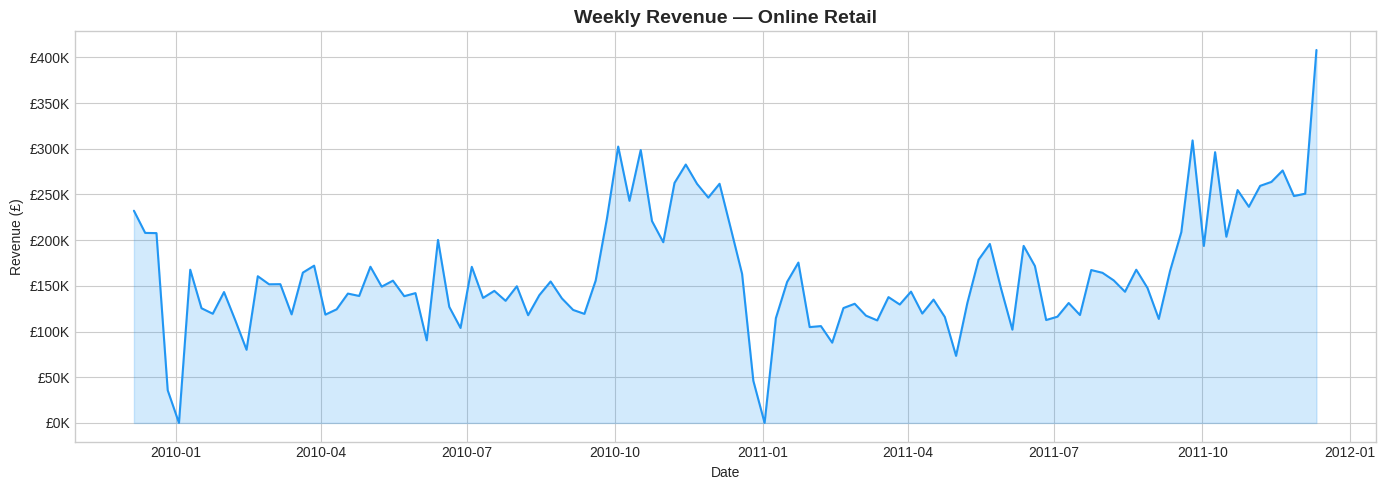

In [29]:
# Resample to weekly for smoother ARIMA
weekly_sales = daily_sales['Revenue'].resample('W').sum()

# Plot weekly sales
plt.figure(figsize=(14, 5))
plt.plot(weekly_sales.index, weekly_sales.values, color='#2196F3', linewidth=1.5)
plt.fill_between(weekly_sales.index, weekly_sales.values, alpha=0.2, color='#2196F3')
plt.title('Weekly Revenue — Online Retail', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('weekly_sales.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Stationarity test — Augmented Dickey-Fuller
result = adfuller(weekly_sales.dropna())
print('=== Augmented Dickey-Fuller Test ===')
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print(f'Critical Values: {result[4]}')
if result[1] < 0.05:
    print('\nResult: Series is STATIONARY (p < 0.05) — no differencing needed')
else:
    print('\nResult: Series is NON-STATIONARY — differencing required (d=1)')

=== Augmented Dickey-Fuller Test ===
ADF Statistic: -2.9437
p-value: 0.0405
Critical Values: {'1%': np.float64(-3.4948504603223145), '5%': np.float64(-2.889758398668639), '10%': np.float64(-2.5818220155325444)}

Result: Series is STATIONARY (p < 0.05) — no differencing needed


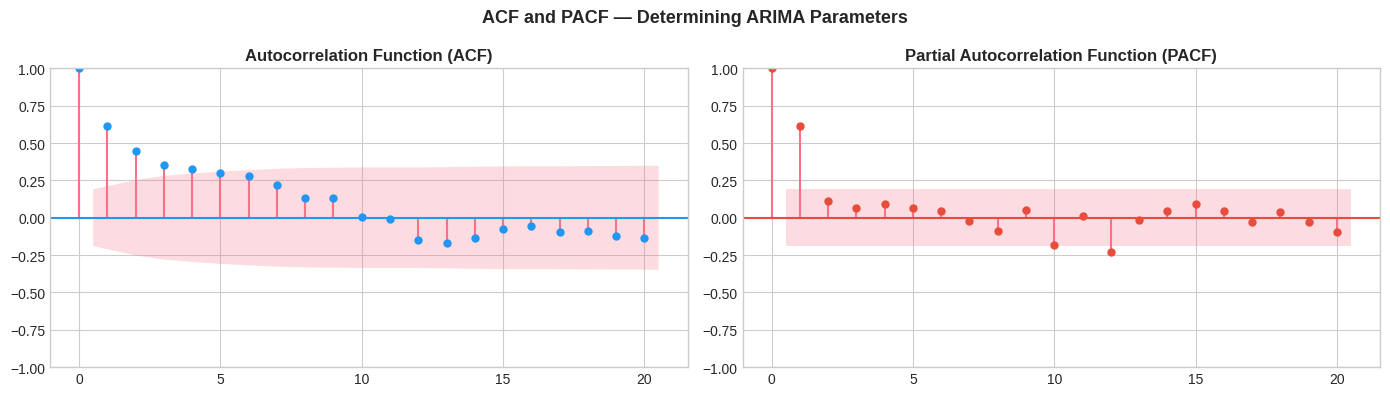

Use ACF to determine q, PACF to determine p


In [31]:
# ACF and PACF plots to determine ARIMA parameters
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('ACF and PACF — Determining ARIMA Parameters', fontsize=13, fontweight='bold')

plot_acf(weekly_sales.dropna(), lags=20, ax=axes[0], color='#2196F3')
axes[0].set_title('Autocorrelation Function (ACF)', fontweight='bold')

plot_pacf(weekly_sales.dropna(), lags=20, ax=axes[1], color='#E74C3C')
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontweight='bold')

plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Use ACF to determine q, PACF to determine p')

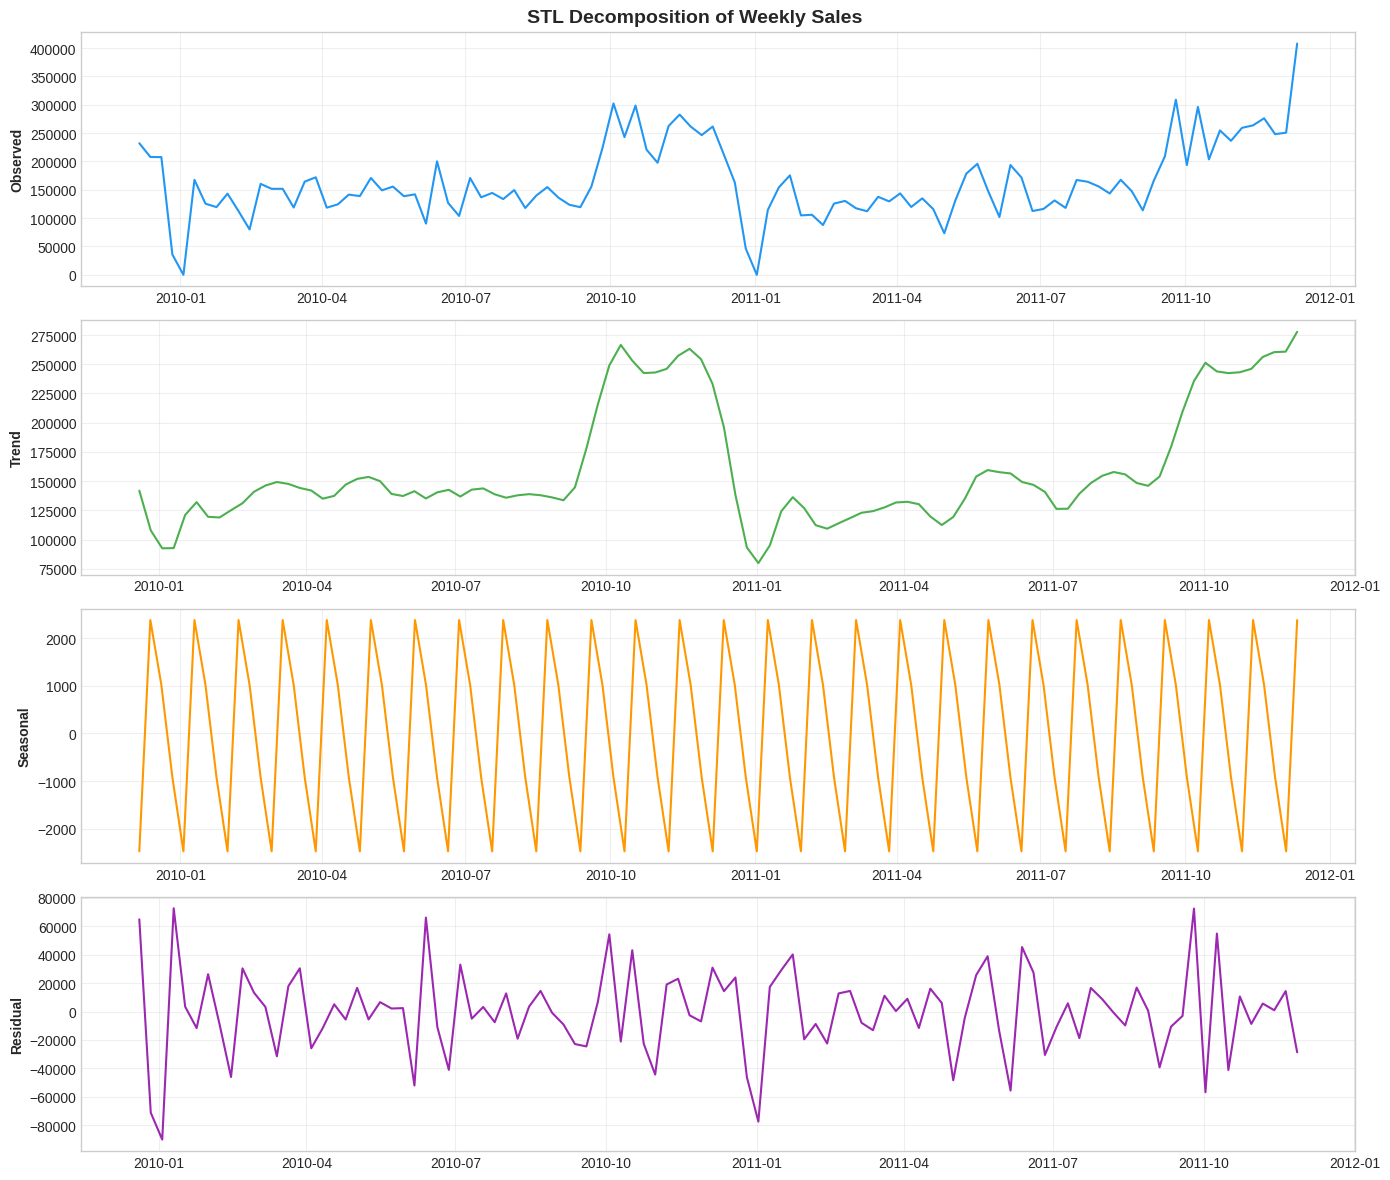

In [32]:
# STL Decomposition
decomposition = seasonal_decompose(weekly_sales.dropna(), model='additive', period=4)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle('STL Decomposition of Weekly Sales', fontsize=14, fontweight='bold')

components = [decomposition.observed, decomposition.trend,
              decomposition.seasonal, decomposition.resid]
labels = ['Observed', 'Trend', 'Seasonal', 'Residual']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for ax, comp, label, color in zip(axes, components, labels, colors):
    ax.plot(comp.index, comp.values, color=color, linewidth=1.5)
    ax.set_ylabel(label, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# ARIMA Model — Train/Test Split (80/20)
train_size = int(len(weekly_sales) * 0.8)
train_arima = weekly_sales[:train_size]
test_arima  = weekly_sales[train_size:]

print(f'Train size: {len(train_arima)} weeks')
print(f'Test size:  {len(test_arima)} weeks')

# Fit ARIMA — adjust (p,d,q) based on your ACF/PACF analysis
arima_model = ARIMA(train_arima, order=(2, 1, 2))
arima_result = arima_model.fit()

print(f'\nARIMA Model Summary:')
print(f'AIC: {arima_result.aic:.2f}')
print(f'BIC: {arima_result.bic:.2f}')

# Forecast
arima_forecast = arima_result.forecast(steps=len(test_arima))
arima_forecast = pd.Series(arima_forecast.values, index=test_arima.index)

# Evaluate
arima_rmse = np.sqrt(mean_squared_error(test_arima, arima_forecast))
arima_mae  = mean_absolute_error(test_arima, arima_forecast)
print(f'\nARIMA Test Results:')
print(f'RMSE: £{arima_rmse:,.2f}')
print(f'MAE:  £{arima_mae:,.2f}')

Train size: 84 weeks
Test size:  22 weeks

ARIMA Model Summary:
AIC: 2021.51
BIC: 2033.60

ARIMA Test Results:
RMSE: £125,185.86
MAE:  £104,401.76


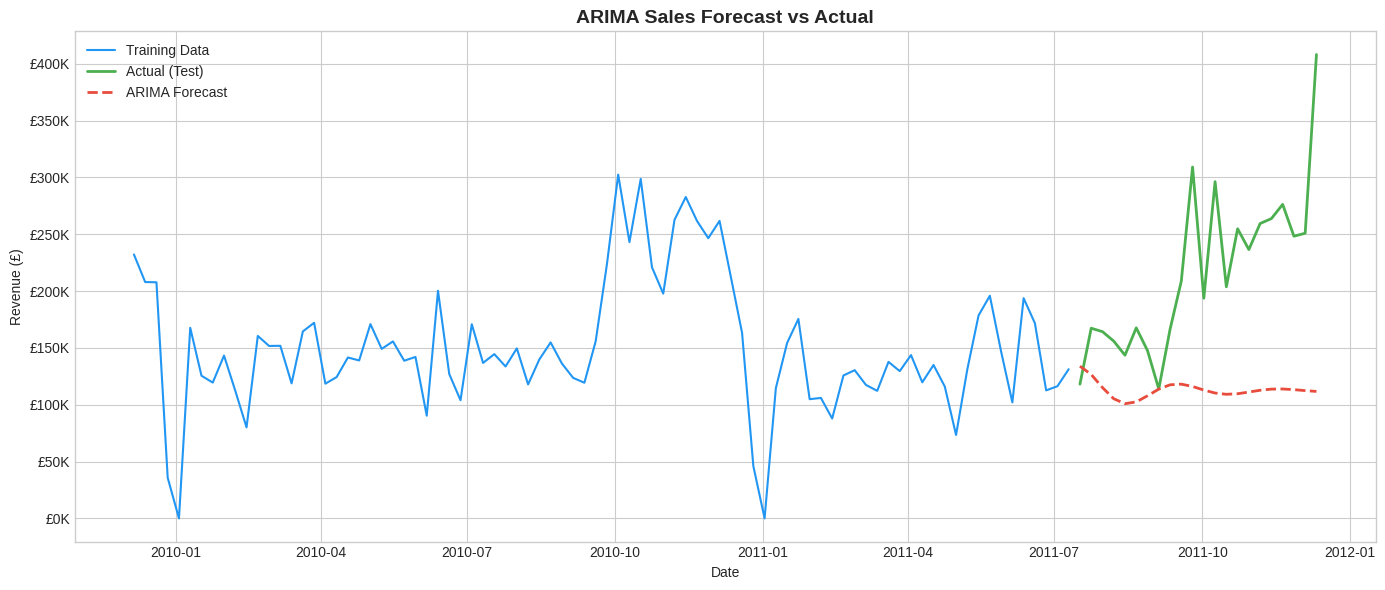

In [34]:
# Plot ARIMA forecast
plt.figure(figsize=(14, 6))
plt.plot(train_arima.index, train_arima.values, label='Training Data', color='#2196F3', linewidth=1.5)
plt.plot(test_arima.index, test_arima.values, label='Actual (Test)', color='#4CAF50', linewidth=2)
plt.plot(arima_forecast.index, arima_forecast.values, label='ARIMA Forecast',
         color='#E74C3C', linewidth=2, linestyle='--')
plt.title('ARIMA Sales Forecast vs Actual', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.legend()
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('arima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

---
### 2B — Random Forest Regression for Short-term Forecasting

In [35]:
# Feature engineering for Random Forest
rf_df = daily_sales.copy().reset_index()
rf_df.columns = ['Date', 'Revenue']

# Time features
rf_df['DayOfWeek']  = rf_df['Date'].dt.dayofweek
rf_df['Month']      = rf_df['Date'].dt.month
rf_df['Week']       = rf_df['Date'].dt.isocalendar().week.astype(int)
rf_df['Quarter']    = rf_df['Date'].dt.quarter
rf_df['DayOfMonth'] = rf_df['Date'].dt.day
rf_df['IsWeekend']  = (rf_df['DayOfWeek'] >= 5).astype(int)

# Lag features — previous days' revenue
for lag in [1, 2, 3, 7, 14]:
    rf_df[f'Lag_{lag}'] = rf_df['Revenue'].shift(lag)

# Rolling window features
rf_df['Rolling_7d_mean']  = rf_df['Revenue'].shift(1).rolling(7).mean()
rf_df['Rolling_14d_mean'] = rf_df['Revenue'].shift(1).rolling(14).mean()
rf_df['Rolling_7d_std']   = rf_df['Revenue'].shift(1).rolling(7).std()

# Drop NaN rows from lag features
rf_df = rf_df.dropna()

feature_cols = ['DayOfWeek', 'Month', 'Week', 'Quarter', 'DayOfMonth', 'IsWeekend',
                'Lag_1', 'Lag_2', 'Lag_3', 'Lag_7', 'Lag_14',
                'Rolling_7d_mean', 'Rolling_14d_mean', 'Rolling_7d_std']

X = rf_df[feature_cols]
y = rf_df['Revenue']

print(f'Features: {len(feature_cols)}')
print(f'Samples: {len(X)}')

Features: 14
Samples: 725


In [36]:
# Time-based train/test split (80/20)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train: {len(X_train)} days | Test: {len(X_test)} days')

# Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

# Evaluate
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_mae  = mean_absolute_error(y_test, rf_predictions)
rf_r2   = rf_model.score(X_test, y_test)

print(f'\nRandom Forest Test Results:')
print(f'RMSE: £{rf_rmse:,.2f}')
print(f'MAE:  £{rf_mae:,.2f}')
print(f'R²:   {rf_r2:.4f}')

Train: 580 days | Test: 145 days

Random Forest Test Results:
RMSE: £17,734.65
MAE:  £9,981.74
R²:   0.4474


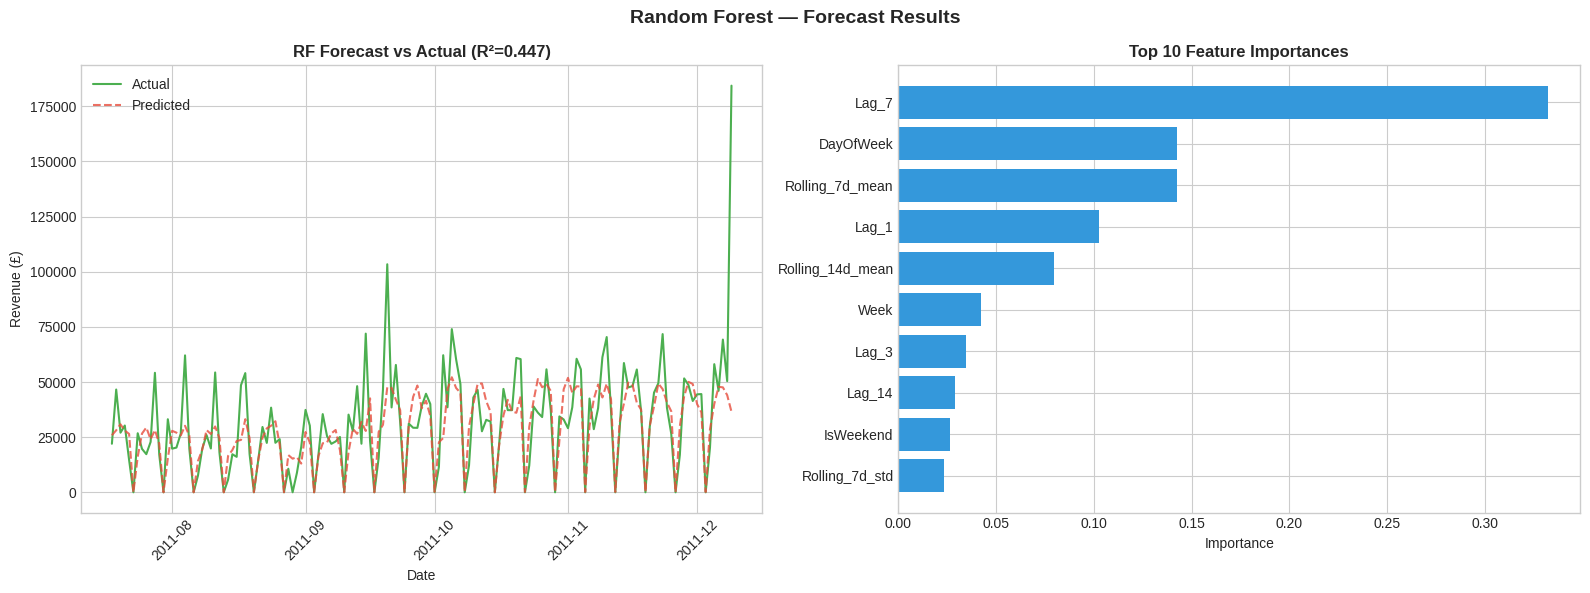

In [37]:
# Feature importance
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Random Forest — Forecast Results', fontsize=14, fontweight='bold')

# Actual vs Predicted
test_dates = rf_df['Date'].iloc[split_idx:]
axes[0].plot(test_dates.values, y_test.values, label='Actual', color='#4CAF50', linewidth=1.5)
axes[0].plot(test_dates.values, rf_predictions, label='Predicted',
             color='#E74C3C', linewidth=1.5, linestyle='--', alpha=0.8)
axes[0].set_title(f'RF Forecast vs Actual (R²={rf_r2:.3f})', fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Revenue (£)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Feature Importance
axes[1].barh(importance_df['Feature'][:10][::-1],
             importance_df['Importance'][:10][::-1], color='#3498DB')
axes[1].set_title('Top 10 Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('rf_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Final Summary — Model Comparison

In [38]:
print('=' * 55)
print('     CUSTOMER SEGMENTATION & FORECASTING SUMMARY')
print('=' * 55)

print(f'\n--- Part 1: Customer Segmentation ---')
print(f'Method:        K-Means Clustering on RFM features')
print(f'Clusters:      {best_k} segments')
print(f'Silhouette:    {silhouette_score(rfm_scaled, rfm["Cluster"]):.3f}')
print(f'Total customers analyzed: {len(rfm):,}')

print(f'\n--- Part 2A: ARIMA Forecasting ---')
print(f'Model:    ARIMA(2,1,2) on weekly sales')
print(f'RMSE:     £{arima_rmse:,.2f}')
print(f'MAE:      £{arima_mae:,.2f}')

print(f'\n--- Part 2B: Random Forest Forecasting ---')
print(f'Model:    Random Forest ({rf_model.n_estimators} trees)')
print(f'Features: {len(feature_cols)} engineered features')
print(f'RMSE:     £{rf_rmse:,.2f}')
print(f'MAE:      £{rf_mae:,.2f}')
print(f'R²:       {rf_r2:.4f}')

print(f'\n--- Business Insight ---')
print(f'Random Forest captures short-term patterns better (lag features).')
print(f'ARIMA is better for long-horizon trend extrapolation.')
print(f'A hybrid pipeline using both gives the most robust forecasts.')
print('=' * 55)

     CUSTOMER SEGMENTATION & FORECASTING SUMMARY

--- Part 1: Customer Segmentation ---
Method:        K-Means Clustering on RFM features
Clusters:      2 segments
Silhouette:    0.419
Total customers analyzed: 5,878

--- Part 2A: ARIMA Forecasting ---
Model:    ARIMA(2,1,2) on weekly sales
RMSE:     £125,185.86
MAE:      £104,401.76

--- Part 2B: Random Forest Forecasting ---
Model:    Random Forest (200 trees)
Features: 14 engineered features
RMSE:     £17,734.65
MAE:      £9,981.74
R²:       0.4474

--- Business Insight ---
Random Forest captures short-term patterns better (lag features).
ARIMA is better for long-horizon trend extrapolation.
A hybrid pipeline using both gives the most robust forecasts.
